# Inference on test_data

This notebook loads `best_random_forest_10b_glcm.pkl` and runs inference on `test_data` without retraining.

Feature contract is aligned with the random_forest_train_12b training setup:
- Spectral subset: `B2,B3,B4,B7,B8,B8A,B11,B12`
- Texture features: `FOCAL_STD_B8,FOCAL_STD_B4,GLCM_B8_CONTRAST,GLCM_B8_DISSIMILARITY,GLCM_B8_ENERGY`
- Spectral indices: `NDVI,NDBI,MNDWI`
- Same normalization rule used in training (`/10000` when needed, then clip to `[0,1]`)

In [31]:
from pathlib import Path
import pickle
import warnings

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
from skimage.feature import graycomatrix, graycoprops
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')

PROJECT_DIR = Path(r'c:/satellite/project')
TEST_DATA_DIR = PROJECT_DIR / 'test_data'
MODEL_PATH = PROJECT_DIR / 'best_random_forest_10b_glcm.pkl'

DEFAULT_CLASS_NAMES = {1: 'Greenery', 2: 'Sand', 3: 'Water', 4: 'Cement'}
CLASS_COLORS = {1: 'darkgreen', 2: 'gold', 3: 'navy', 4: 'gray'}
EPS = 1e-6

# Postprocessing config (majority-vote smoothing on predicted labels).
POSTPROCESS_ENABLE = False
POSTPROCESS_WINDOW = 3

with open(MODEL_PATH, 'rb') as f:
    model_payload = pickle.load(f)

model = model_payload['model']
model_type = model_payload.get('model_type', type(model).__name__)
model_feature_names = model_payload['feature_names']
CLASS_NAMES = model_payload.get('class_names', DEFAULT_CLASS_NAMES)
# Ensure Class 0 is explicitly ignored if present
CLASS_NAMES = {k: v for k, v in CLASS_NAMES.items() if k != 0}
CLASS_IDS = sorted(CLASS_NAMES.keys())
ACTIVE_CLASSES = CLASS_IDS

spectral_files = sorted(TEST_DATA_DIR.glob('*_Spectral_12B.tif'))
mask_files = sorted(TEST_DATA_DIR.glob('*_Mask_Class.tif'))

def pair_id(path: Path) -> str:
    name = path.name
    name = name.replace('_Spectral_12B.tif', '')
    name = name.replace('_Mask_Class.tif', '')
    return name

spectral_lookup = {pair_id(path): path for path in spectral_files}
mask_lookup = {pair_id(path): path for path in mask_files}
common_ids = sorted(set(spectral_lookup) & set(mask_lookup))
sample_pairs = [
    {
        'name': site_id,
        'spectral_path': spectral_lookup[site_id],
        'mask_path': mask_lookup[site_id],
    }
    for site_id in common_ids
]

print(f'Model path: {MODEL_PATH}')
print(f'Model type: {model_type}')
print(f'Test data directory: {TEST_DATA_DIR}')
print(f'Paired test samples: {[item["name"] for item in sample_pairs]}')
print(f'Classes: {CLASS_NAMES}')
print(f'Model feature count: {len(model_feature_names)}')
print(f'Postprocessing enabled: {POSTPROCESS_ENABLE} | window={POSTPROCESS_WINDOW}')
print(f'Unmatched spectral files: {len(set(spectral_lookup) - set(mask_lookup))}')
print(f'Unmatched mask files: {len(set(mask_lookup) - set(spectral_lookup))}')

Model path: c:\satellite\project\best_random_forest_10b_glcm.pkl
Model type: random_forest
Test data directory: c:\satellite\project\test_data
Paired test samples: ['CairoUniv', 'HawaraFayoum', 'IconicTower', 'KarnakLuxor', 'PhilaeAswan', 'SiwaOasis']
Classes: {1: 'Greenery', 2: 'Sand', 3: 'Water', 4: 'Cement'}
Model feature count: 16
Postprocessing enabled: False | window=3
Unmatched spectral files: 0
Unmatched mask files: 0


In [19]:
sample_item = sample_pairs[0]
sample_name = sample_item['name']
sample_spectral_path = sample_item['spectral_path']
sample_mask_path = sample_item['mask_path']

with rasterio.open(sample_spectral_path) as src:
    sample_band_count = src.count
    sample_shape = (src.count, src.height, src.width)
    sample_dtype = src.dtypes[0]
    sample_descriptions = src.descriptions

with rasterio.open(sample_mask_path) as src:
    sample_mask = src.read(1)
    sample_mask_values = np.unique(sample_mask)

print(f'Sample: {sample_name}')
print(f'Spectral shape: {sample_shape} | dtype={sample_dtype}')
print(f'Spectral band count: {sample_band_count}')
print(f'Band descriptions: {sample_descriptions}')
print(f'Mask unique values: {sample_mask_values.tolist()}')
assert sample_band_count == 12, f'Expected 12-band test_data imagery, got {sample_band_count} bands.'

Sample: CairoUniv
Spectral shape: (12, 301, 346) | dtype=float64
Spectral band count: 12
Band descriptions: ('B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12')
Mask unique values: [1, 2, 3, 4]


In [20]:
# test_data band order:
# idx: 0  1  2  3  4  5  6  7   8   9   10   11
# band:B1 B2 B3 B4 B5 B6 B7 B8  B8A  B9  B11  B12
# random_forest_train_12b feature contract:
# spectral subset: B2,B3,B4,B7,B8,B8A,B11,B12
# focal std: FOCAL_STD_B8,FOCAL_STD_B4
# glcm: GLCM_B8_CONTRAST,GLCM_B8_DISSIMILARITY,GLCM_B8_ENERGY
# indices: NDVI,NDBI,MNDWI

IDX_B2 = 1
IDX_B3 = 2
IDX_B4 = 3
IDX_B5 = 4
IDX_B6 = 5
IDX_B7 = 6
IDX_B8 = 7
IDX_B8A = 8
IDX_B11 = 10
IDX_B12 = 11

SPECTRAL_10_NAMES = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
SPECTRAL_SUBSET_NAMES = ['B2', 'B3', 'B4', 'B7', 'B8', 'B8A', 'B11', 'B12']
SPECTRAL_SUBSET_IDX = [SPECTRAL_10_NAMES.index(b) for b in SPECTRAL_SUBSET_NAMES]
IDX10_B3 = SPECTRAL_10_NAMES.index('B3')
IDX10_B4 = SPECTRAL_10_NAMES.index('B4')
IDX10_B8 = SPECTRAL_10_NAMES.index('B8')
IDX10_B11 = SPECTRAL_10_NAMES.index('B11')

FOCAL_WINDOW = 5
GLCM_WINDOW = 7
GLCM_LEVELS = 16
GLCM_ANGLES = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]
GLCM_PROPS = ['contrast', 'dissimilarity', 'energy']

INFER_FEATURE_NAMES = (
    SPECTRAL_SUBSET_NAMES
    + ['FOCAL_STD_B8', 'FOCAL_STD_B4']
    + [f'GLCM_B8_{p.upper()}' for p in GLCM_PROPS]
    + ['NDVI', 'NDBI', 'MNDWI']
)

def local_mean_std_2d(band_2d: np.ndarray, window: int = 5):
    pad = window // 2
    padded = np.pad(band_2d, ((pad, pad), (pad, pad)), mode='reflect')
    windows = np.lib.stride_tricks.sliding_window_view(padded, (window, window))
    mean_map = windows.mean(axis=(-1, -2))
    std_map = windows.std(axis=(-1, -2))
    return mean_map.astype(np.float32), std_map.astype(np.float32)

def normalize_spectral_10(spectral_cube: np.ndarray) -> np.ndarray:
    spectral_raw = np.stack([
        spectral_cube[IDX_B2].astype(np.float32),
        spectral_cube[IDX_B3].astype(np.float32),
        spectral_cube[IDX_B4].astype(np.float32),
        spectral_cube[IDX_B5].astype(np.float32),
        spectral_cube[IDX_B6].astype(np.float32),
        spectral_cube[IDX_B7].astype(np.float32),
        spectral_cube[IDX_B8].astype(np.float32),
        spectral_cube[IDX_B8A].astype(np.float32),
        spectral_cube[IDX_B11].astype(np.float32),
        spectral_cube[IDX_B12].astype(np.float32),
    ], axis=0)
    spectral_scale_probe = np.nanpercentile(spectral_raw, 99)
    if spectral_scale_probe > 2.0:
        spectral_norm = np.clip(spectral_raw / 10000.0, 0.0, 1.0)
    else:
        spectral_norm = np.clip(spectral_raw, 0.0, 1.0)
    return spectral_norm

def quantize_for_glcm(band_2d: np.ndarray, levels: int = 16) -> np.ndarray:
    return np.floor(np.clip(band_2d, 0.0, 1.0) * (levels - 1)).astype(np.uint8)

def compute_spectral_indices(spectral_norm: np.ndarray) -> np.ndarray:
    b3 = spectral_norm[IDX10_B3]
    b4 = spectral_norm[IDX10_B4]
    b8 = spectral_norm[IDX10_B8]
    b11 = spectral_norm[IDX10_B11]
    ndvi = (b8 - b4) / (b8 + b4 + EPS)
    ndbi = (b11 - b8) / (b11 + b8 + EPS)
    mndwi = (b3 - b11) / (b3 + b11 + EPS)
    return np.stack([ndvi, ndbi, mndwi], axis=0).astype(np.float32)

def glcm_features_for_indices(
    b8_quantized: np.ndarray,
    flat_indices: np.ndarray,
    image_shape,
    window: int = 7,
    levels: int = 16,
    props=None,
 ):
    if props is None:
        props = GLCM_PROPS
    h, w = image_shape
    pad = window // 2
    padded = np.pad(b8_quantized, ((pad, pad), (pad, pad)), mode='reflect')
    rows = flat_indices // w
    cols = flat_indices % w
    out = np.zeros((flat_indices.shape[0], len(props)), dtype=np.float32)
    for i, (r, c) in enumerate(zip(rows, cols)):
        patch = padded[r:r + window, c:c + window]
        glcm = graycomatrix(
            patch,
            distances=[1],
            angles=GLCM_ANGLES,
            levels=levels,
            symmetric=True,
            normed=True,
        )
        for j, p in enumerate(props):
            out[i, j] = np.mean(graycoprops(glcm, p)[0])
    return out

def build_inference_features(spectral_cube: np.ndarray) -> np.ndarray:
    spectral_norm = normalize_spectral_10(spectral_cube)

    spectral_subset = spectral_norm[SPECTRAL_SUBSET_IDX]
    spectral_flat = np.moveaxis(spectral_subset, 0, -1).reshape(-1, len(SPECTRAL_SUBSET_IDX))

    b8 = spectral_norm[IDX10_B8]
    b4 = spectral_norm[IDX10_B4]
    _, b8_std = local_mean_std_2d(b8, window=FOCAL_WINDOW)
    _, b4_std = local_mean_std_2d(b4, window=FOCAL_WINDOW)
    focal_maps = np.stack([b8_std, b4_std], axis=0)
    focal_flat = np.moveaxis(focal_maps, 0, -1).reshape(-1, 2)

    h, w = b8.shape
    all_indices = np.arange(h * w, dtype=np.int64)
    b8_quantized = quantize_for_glcm(b8, levels=GLCM_LEVELS)
    glcm_flat = glcm_features_for_indices(
        b8_quantized=b8_quantized,
        flat_indices=all_indices,
        image_shape=(h, w),
        window=GLCM_WINDOW,
        levels=GLCM_LEVELS,
        props=GLCM_PROPS,
    )

    index_maps = compute_spectral_indices(spectral_norm)
    index_flat = np.moveaxis(index_maps, 0, -1).reshape(-1, 3)

    return np.concatenate([spectral_flat, focal_flat, glcm_flat, index_flat], axis=1).astype(np.float32)

print('Inference feature count:', len(INFER_FEATURE_NAMES))
print('Matches saved model feature contract:', INFER_FEATURE_NAMES == model_feature_names)
assert INFER_FEATURE_NAMES == model_feature_names, 'Inference features do not match the saved model feature order.'

Inference feature count: 16
Matches saved model feature contract: True


In [21]:
def compute_per_class_iou(y_true: np.ndarray, y_pred: np.ndarray, class_ids):
    ious = {}
    for class_id in class_ids:
        intersection = np.sum((y_true == class_id) & (y_pred == class_id))
        union = np.sum((y_true == class_id) | (y_pred == class_id))
        ious[class_id] = intersection / union if union > 0 else np.nan
    return ious

def majority_vote_smoothing(label_map: np.ndarray, class_ids, window: int = 3) -> np.ndarray:
    if window <= 1:
        return label_map
    if window % 2 == 0:
        raise ValueError('POSTPROCESS_WINDOW must be odd for centered voting.')

    pad = window // 2
    padded = np.pad(label_map, ((pad, pad), (pad, pad)), mode='reflect')
    patches = np.lib.stride_tricks.sliding_window_view(padded, (window, window))

    class_ids = np.array(class_ids, dtype=np.int32)
    vote_counts = np.stack([
        np.sum(patches == class_id, axis=(-1, -2))
        for class_id in class_ids
    ], axis=-1)

    winners = np.argmax(vote_counts, axis=-1)
    return class_ids[winners].astype(label_map.dtype)

def make_rgb(spectral_cube: np.ndarray) -> np.ndarray:
    red = spectral_cube[IDX_B4].astype(np.float32)
    green = spectral_cube[IDX_B3].astype(np.float32)
    blue = spectral_cube[IDX_B2].astype(np.float32)
    rgb = np.stack([red, green, blue], axis=-1)
    p2, p98 = np.percentile(rgb, [2, 98])
    return np.clip((rgb - p2) / (p98 - p2 + EPS), 0, 1)

cmap_cls = ListedColormap([CLASS_COLORS[c] for c in CLASS_IDS])
bounds = np.arange(min(CLASS_IDS) - 0.5, max(CLASS_IDS) + 1.5, 1)
norm_cls = BoundaryNorm(bounds, ncolors=len(CLASS_IDS))
legend_patches = [mpatches.Patch(color=CLASS_COLORS[c], label=f'{c}: {CLASS_NAMES[c]}') for c in CLASS_IDS]

In [32]:
records = []
predictions_by_site = {}

for sample_item in sample_pairs:
    sample_name = sample_item['name']
    spectral_path = sample_item['spectral_path']
    mask_path = sample_item['mask_path']

    with rasterio.open(spectral_path) as src:
        spectral_cube = src.read().astype(np.float32)

    with rasterio.open(mask_path) as src:
        y_true = src.read(1).astype(np.int32)

    features = build_inference_features(spectral_cube)
    y_pred_raw = model.predict(features).reshape(y_true.shape).astype(np.int32)

    if POSTPROCESS_ENABLE:
        y_pred = majority_vote_smoothing(y_pred_raw, CLASS_IDS, window=POSTPROCESS_WINDOW)
    else:
        y_pred = y_pred_raw

    # Ignore class 0 if it exists in y_true but isn't handled by the model.
    # To do this safely, we mask out pixels where y_true == 0
    valid_mask = (y_true != 0)
    
    # We pass flattened valid arrays for iou compute to avoid punishing the model
    # for class 0, which we dropped.
    y_true_valid = y_true[valid_mask]
    y_pred_valid = y_pred[valid_mask]

    ious = compute_per_class_iou(y_true_valid, y_pred_valid, ACTIVE_CLASSES)
    miou = float(np.nanmean([ious[c] for c in ACTIVE_CLASSES]))
    accuracy = float(np.mean(y_true_valid == y_pred_valid))

    row = {
        'sample': sample_name,
        'accuracy': accuracy,
        'mIoU_active': miou
    }
    for class_id in ACTIVE_CLASSES:
        row[f'IoU_{CLASS_NAMES[class_id]}'] = ious[class_id]
    records.append(row)

    predictions_by_site[sample_name] = {
        'spectral_cube': spectral_cube,
        'y_true': y_true,           # keep original for plotting
        'y_true_valid': y_true_valid, # keep valid for global metrics
        'y_pred_raw': y_pred_raw,
        'y_pred': y_pred,
        'y_pred_valid': y_pred_valid # keep valid for global metrics
    }

metrics_df = pd.DataFrame(records).sort_values('mIoU_active', ascending=False).reset_index(drop=True)
metrics_df

,sample,accuracy,mIoU_active,IoU_Greenery,IoU_Sand,IoU_Water,IoU_Cement
0,SiwaOasis,0.715477,0.578395,0.605664,0.359240,0.768600,0.580078
1,KarnakLuxor,0.735080,0.499339,0.673602,0.348899,0.224066,0.750790
2,CairoUniv,0.878757,0.464226,0.345004,0.064634,0.524706,0.922562
3,HawaraFayoum,0.821313,0.447642,0.876815,0.663741,0.015094,0.234918
4,IconicTower,0.702303,0.359656,0.174390,0.668930,0.228426,0.366879
5,PhilaeAswan,0.247220,0.178427,0.173851,0.194904,0.204565,0.140387


In [23]:
print('Mean active-class mIoU:', round(metrics_df['mIoU_active'].mean(), 4))
print('Mean accuracy:', round(metrics_df['accuracy'].mean(), 4))
print(f'Postprocessing enabled: {POSTPROCESS_ENABLE} | window={POSTPROCESS_WINDOW}')
print('\nPer-sample metrics:')
for _, row in metrics_df.iterrows():
    print(f"{row['sample']:<15} mIoU={row['mIoU_active']:.4f}  acc={row['accuracy']:.4f}")

Mean active-class mIoU: 0.337
Mean accuracy: 0.6833
Postprocessing enabled: False | window=3

Per-sample metrics:
SiwaOasis       mIoU=0.4627  acc=0.7155
KarnakLuxor     mIoU=0.3995  acc=0.7351
CairoUniv       mIoU=0.3714  acc=0.8788
HawaraFayoum    mIoU=0.3581  acc=0.8213
IconicTower     mIoU=0.2877  acc=0.7023
PhilaeAswan     mIoU=0.1426  acc=0.2466


              precision    recall  f1-score   support

    Greenery       0.83      0.80      0.82    149024
        Sand       0.95      0.55      0.69    165917
       Water       0.98      0.27      0.42     88283
      Cement       0.65      0.89      0.75    210318

   micro avg       0.76      0.69      0.72    613542
   macro avg       0.85      0.63      0.67    613542
weighted avg       0.82      0.69      0.70    613542



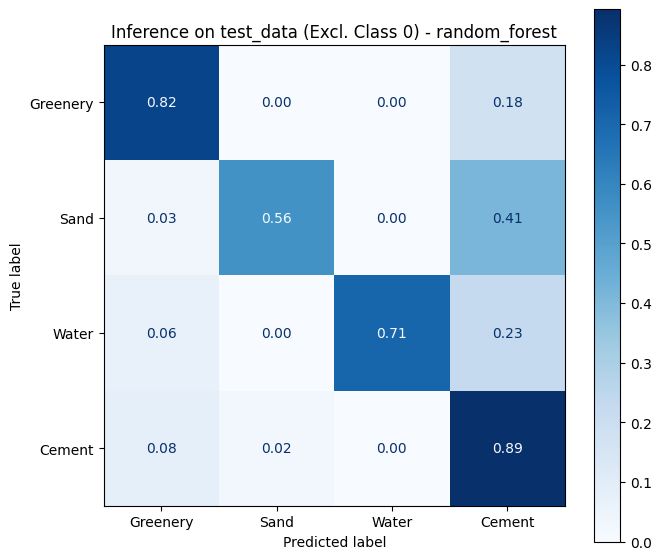

In [33]:
# We evaluate metrics ONLY on valid pixels (excluding class 0)
all_true = np.concatenate([predictions_by_site[item]['y_true_valid'] for item in predictions_by_site])
all_pred = np.concatenate([predictions_by_site[item]['y_pred_valid'] for item in predictions_by_site])

print(classification_report(
    all_true,
    all_pred,
    labels=CLASS_IDS,
    target_names=[CLASS_NAMES[c] for c in CLASS_IDS],
    zero_division=0
))

cm = confusion_matrix(all_true, all_pred, labels=CLASS_IDS, normalize='true')
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[CLASS_NAMES[c] for c in CLASS_IDS]
).plot(ax=ax, cmap='Blues', values_format='.2f', colorbar=True)
ax.set_title(f'Inference on test_data (Excl. Class 0) - {model_type}')
plt.tight_layout()
plt.show()

In [30]:
print("Predictions:", np.unique(all_pred, return_counts=True))
print("Truth:", np.unique(all_true, return_counts=True))

Predictions: (array([0, 1, 2, 3, 4], dtype=int32), array([ 61683, 143588,  96346,  24375, 287791]))
Truth: (array([0, 1, 2, 3, 4], dtype=int32), array([   241, 149024, 165917,  88283, 210318]))


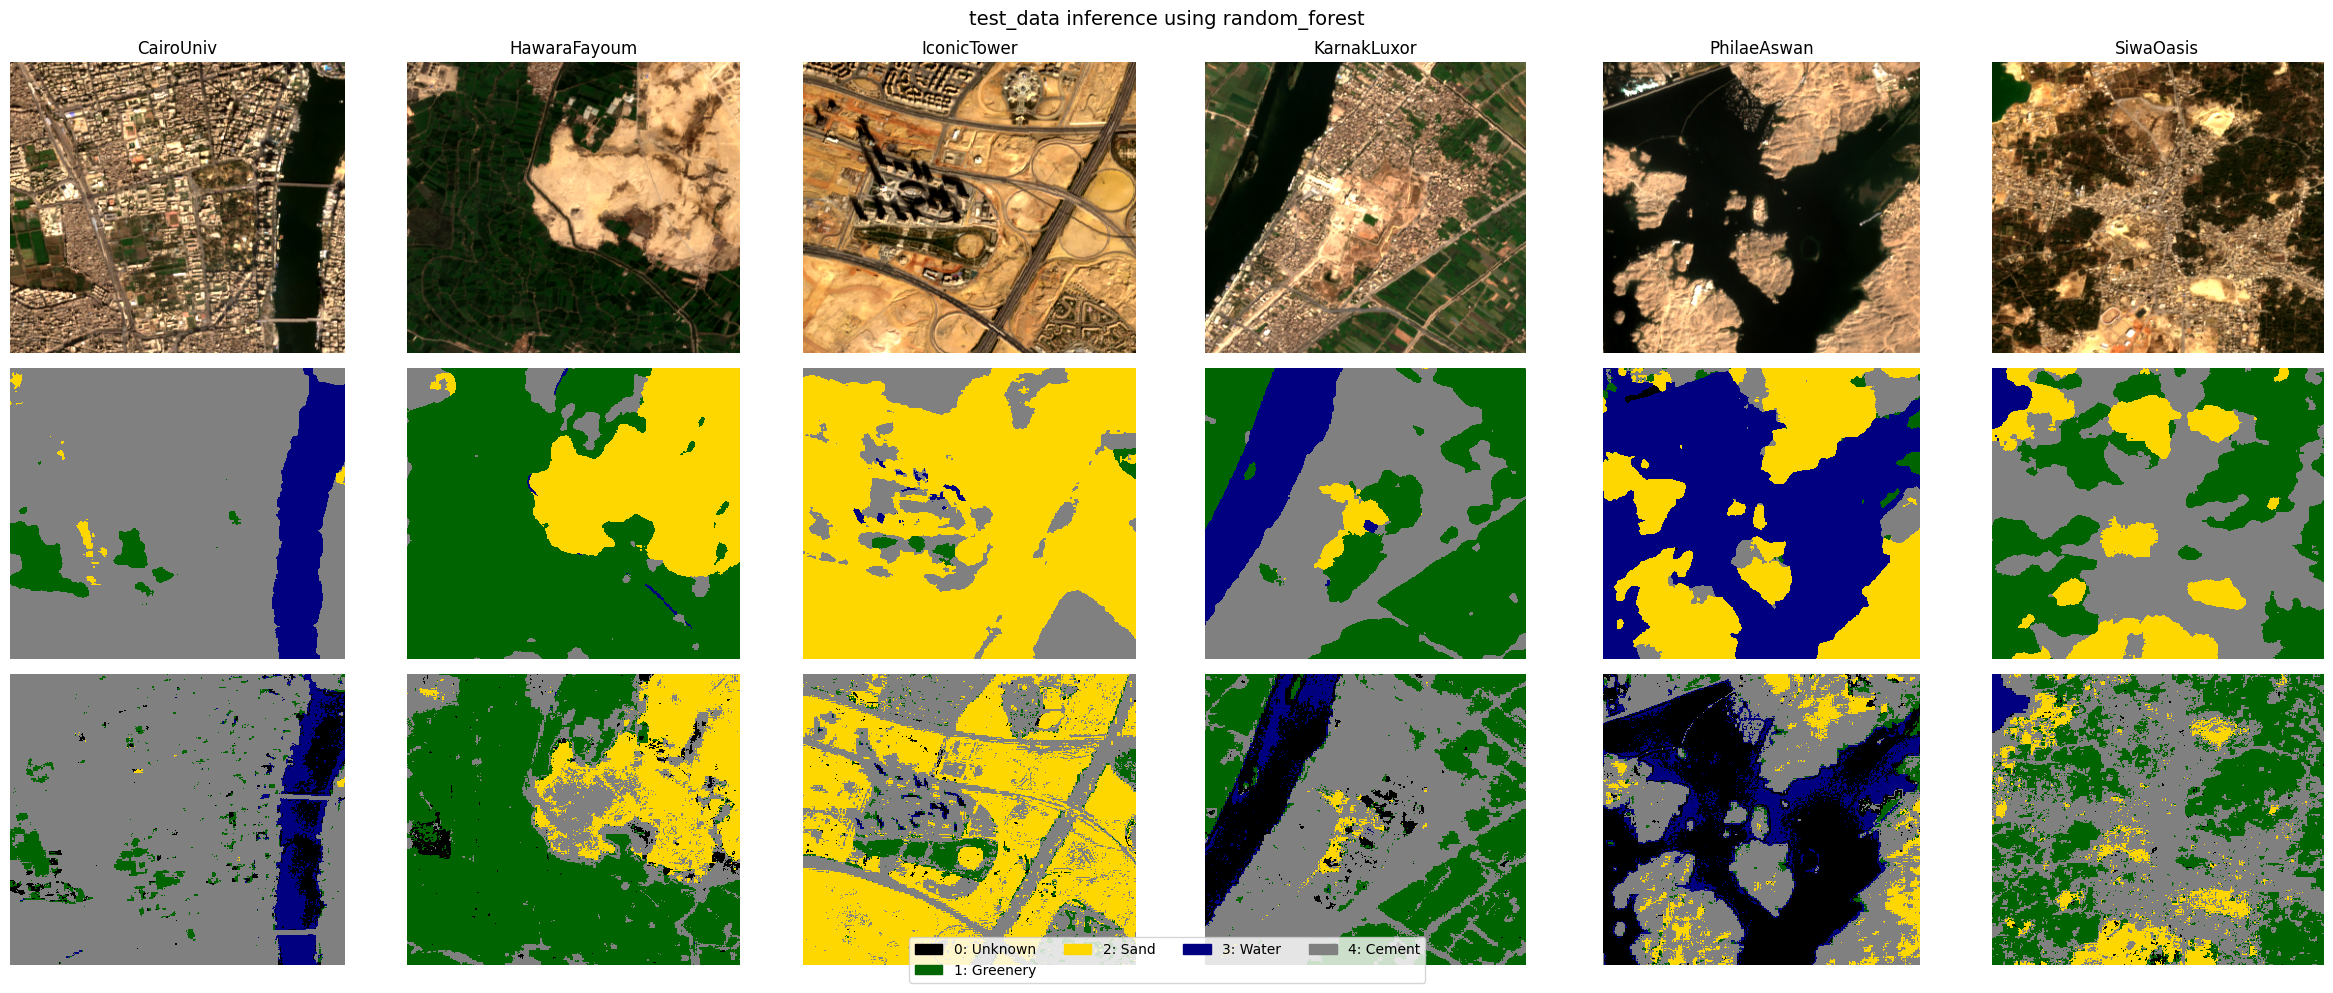

In [34]:
n_samples = len(sample_pairs)
n_rows = 4 if POSTPROCESS_ENABLE else 3
fig, axes = plt.subplots(n_rows, n_samples, figsize=(4 * n_samples, 3.3 * n_rows))

if n_samples == 1:
    axes = np.array(axes).reshape(n_rows, 1)

for col, sample_item in enumerate(sample_pairs):
    sample_name = sample_item['name']
    bundle = predictions_by_site[sample_name]
    rgb = make_rgb(bundle['spectral_cube'])

    axes[0, col].imshow(rgb)
    axes[0, col].set_title(sample_name)
    axes[0, col].axis('off')

    axes[1, col].imshow(bundle['y_true'], cmap=cmap_cls, norm=norm_cls, interpolation='nearest')
    axes[1, col].axis('off')

    if POSTPROCESS_ENABLE:
        axes[2, col].imshow(bundle['y_pred_raw'], cmap=cmap_cls, norm=norm_cls, interpolation='nearest')
        axes[2, col].axis('off')

        axes[3, col].imshow(bundle['y_pred'], cmap=cmap_cls, norm=norm_cls, interpolation='nearest')
        axes[3, col].axis('off')
    else:
        axes[2, col].imshow(bundle['y_pred'], cmap=cmap_cls, norm=norm_cls, interpolation='nearest')
        axes[2, col].axis('off')

axes[0, 0].set_ylabel('RGB', fontsize=10)
axes[1, 0].set_ylabel('Ground Truth', fontsize=10)
if POSTPROCESS_ENABLE:
    axes[2, 0].set_ylabel('Prediction (Raw)', fontsize=10)
    axes[3, 0].set_ylabel('Prediction (Smoothed)', fontsize=10)
else:
    axes[2, 0].set_ylabel('Prediction', fontsize=10)

fig.legend(handles=legend_patches, loc='lower center', ncol=len(CLASS_IDS), bbox_to_anchor=(0.5, -0.01))
plt.suptitle(f'test_data inference using {model_type}', fontsize=14)
plt.tight_layout()
plt.show()

In [35]:
metrics_path = PROJECT_DIR / 'test_data_inference_metrics.csv'
metrics_df.to_csv(metrics_path, index=False)
print(f'Saved metrics: {metrics_path}')

Saved metrics: c:\satellite\project\test_data_inference_metrics.csv


In [36]:
# Diagnostic: why class 0 (Unknown) fails
from pathlib import Path
from sklearn.metrics import precision_recall_fscore_support

train_mask_paths = sorted((PROJECT_DIR / 'new_dataset').glob('*_msk.tif'))
test_mask_paths = sorted((PROJECT_DIR / 'test_data').glob('*_Mask_Class.tif'))
classes = sorted(CLASS_IDS)

def dataset_class_stats(mask_paths, classes):
    counts = {c: 0 for c in classes}
    img_presence = {c: 0 for c in classes}
    for mpath in mask_paths:
        with rasterio.open(mpath) as src:
            m = src.read(1)
        vals, cnts = np.unique(m, return_counts=True)
        present = set(int(v) for v in vals.tolist())
        for v, c in zip(vals, cnts):
            v = int(v)
            if v in counts:
                counts[v] += int(c)
        for c in classes:
            if c in present:
                img_presence[c] += 1
    total = sum(counts.values())
    pct = {c: (counts[c] / total * 100 if total > 0 else 0.0) for c in classes}
    return counts, pct, img_presence, total

train_counts, train_pct, train_presence, train_total = dataset_class_stats(train_mask_paths, classes)
test_counts, test_pct, test_presence, test_total = dataset_class_stats(test_mask_paths, classes)

print('=== Raw Mask Distribution ===')
print(f'Train masks: {len(train_mask_paths)} | total px: {train_total:,}')
for c in classes:
    print(f"  class {c} ({CLASS_NAMES[c]}): {train_counts[c]:,} px ({train_pct[c]:.3f}%), present in {train_presence[c]}/{len(train_mask_paths)} images")

print(f'\nTest masks: {len(test_mask_paths)} | total px: {test_total:,}')
for c in classes:
    print(f"  class {c} ({CLASS_NAMES[c]}): {test_counts[c]:,} px ({test_pct[c]:.3f}%), present in {test_presence[c]}/{len(test_mask_paths)} images")

# Per-class precision/recall from current inference results
prec, rec, f1, support = precision_recall_fscore_support(
    all_true,
    all_pred,
    labels=classes,
    zero_division=0
)

print('\n=== Inference Precision/Recall/F1 ===')
for i, c in enumerate(classes):
    print(f"  class {c} ({CLASS_NAMES[c]}): precision={prec[i]:.4f}, recall={rec[i]:.4f}, f1={f1[i]:.4f}, support={support[i]:,}")

# Training sampled counts if notebook / payload exposes them
if 'y_train' in globals() and 'y_val' in globals():
    y_all = np.concatenate([y_train, y_val])
    print('\n=== Sampled Training Set Distribution (from notebook splits) ===')
    for c in classes:
        cc = int(np.sum(y_all == c))
        print(f"  class {c} ({CLASS_NAMES[c]}): {cc:,}")
else:
    print('\n(No y_train/y_val variables in this notebook context; training run reported class-0 under-target in prior notebook output.)')

=== Raw Mask Distribution ===
Train masks: 517 | total px: 33,834,642
  class 1 (Greenery): 6,091,611 px (18.004%), present in 169/517 images
  class 2 (Sand): 11,997,934 px (35.461%), present in 301/517 images
  class 3 (Water): 8,068,171 px (23.846%), present in 174/517 images
  class 4 (Cement): 7,676,926 px (22.690%), present in 222/517 images

Test masks: 6 | total px: 613,542
  class 1 (Greenery): 149,024 px (24.289%), present in 6/6 images
  class 2 (Sand): 165,917 px (27.042%), present in 6/6 images
  class 3 (Water): 88,283 px (14.389%), present in 6/6 images
  class 4 (Cement): 210,318 px (34.279%), present in 6/6 images

=== Inference Precision/Recall/F1 ===
  class 1 (Greenery): precision=0.8347, recall=0.8043, f1=0.8192, support=149,024
  class 2 (Sand): precision=0.9450, recall=0.5488, f1=0.6943, support=165,917
  class 3 (Water): precision=0.9763, recall=0.2695, f1=0.4225, support=88,283
  class 4 (Cement): precision=0.6493, recall=0.8877, f1=0.7500, support=210,318

(No